# Initialization

In [1]:
# ---- Patch 0: safer GPU config (run once, near the top) ----
import tensorflow as tf
tf.config.set_soft_device_placement(True)  # let TF fallback to CPU if needed

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU(s) found and memory growth enabled: {gpus}")
    except Exception as e:
        print("Could not enable memory growth:", e)
else:
    print("No GPU detected; running on CPU.")


2025-08-22 21:23:21.380937: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-22 21:23:21.390680: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755885201.402078  160929 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755885201.405630  160929 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755885201.418043  160929 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

GPU(s) found and memory growth enabled: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import glob
import numpy as np

npy_files = glob.glob('cached_np/*.npy')
data_arrays = {file.split('/')[-1].replace('.npy', ''): np.load(file) for file in npy_files}

print(f"Loaded {len(data_arrays)} variables from .npy files.")


Loaded 7 variables from .npy files.


# Preprocessing

In [3]:
vars_to_check = [
    'X_all',
    'Y_all',
    'wrench_all',
    'Z_all',
    'angles_all',
    'wrench_out_all',
    'currents_all'
]

for name in vars_to_check:
    if name in data_arrays:
        arr = np.array(data_arrays[name])
        print(f"{name}: shape={arr.shape}, dtype={arr.dtype}, "
              f"min={np.nanmin(arr):.6f}, max={np.nanmax(arr):.6f}, "
              f"NaNs={np.isnan(arr).sum()}")
    else:
        print(f"{name}: NOT FOUND in data_arrays")


X_all: shape=(1, 1411344), dtype=float64, min=-0.150000, max=0.150000, NaNs=0
Y_all: shape=(1, 1411344), dtype=float64, min=-0.150000, max=0.150000, NaNs=0
wrench_all: shape=(6, 1411344), dtype=float64, min=-71.323061, max=67.910946, NaNs=0
Z_all: shape=(1, 1411344), dtype=float64, min=0.005000, max=0.005000, NaNs=0
angles_all: shape=(3, 1411344), dtype=float64, min=-3.141593, max=3.141593, NaNs=0
wrench_out_all: shape=(6, 1411344), dtype=float64, min=-43712933.130251, max=36944979.677285, NaNs=0
currents_all: shape=(16, 1411344), dtype=float64, min=-5885.689556, max=16889.743946, NaNs=0


In [4]:
# Build ARR as [N,16] from whatever you loaded. Then re-run the previous analysis cell.

import numpy as np

def find_currents_matrix(dct):
    # 2D with 16 cols
    for v in dct.values():
        a = np.array(v)
        if a.ndim == 2 and a.shape[1] == 16:
            return a
    # 2D with 16 rows -> transpose
    for v in dct.values():
        a = np.array(v)
        if a.ndim == 2 and a.shape[0] == 16:
            return a.T
    # 1D or weird -> reshape by 16
    for v in dct.values():
        a = np.array(v).ravel()
        if a.size % 16 == 0 and a.size >= 16:
            return a.reshape(-1, 16)
    raise ValueError("No 16-current structure found in data_arrays.")

ARR = find_currents_matrix(data_arrays)
print("ARR shape:", ARR.shape)

ARR shape: (1411344, 16)


In [5]:
# Ensure shape is [N_samples, N_channels]
W = np.array(data_arrays['wrench_out_all'], dtype=float)
if W.shape[0] < W.shape[1]:
    W = W.T  # transpose to get samples as rows

print("Fixed wrench_out_all shape:", W.shape)  # should be (1895400, 6)

Fixed wrench_out_all shape: (1411344, 6)


In [6]:
import numpy as np

# Preprocess into sample-aligned arrays

def to_samples_first(arr):
    arr = np.array(arr, dtype=float)
    if arr.shape[0] < arr.shape[1]:
        arr = arr.T
    return arr

# Flatten small coordinate arrays
def flatten_coord(arr):
    return np.array(arr, dtype=float).ravel()

X_all = flatten_coord(data_arrays['X_all'])
Y_all = flatten_coord(data_arrays['Y_all'])
Z_all = flatten_coord(data_arrays['Z_all'])
angles_all = np.array(data_arrays['angles_all'], dtype=float)
if angles_all.shape[0] < angles_all.shape[1]:
    angles_all = angles_all.T  # now shape [N, 3]

wrench_all = to_samples_first(data_arrays['wrench_all'])          # [N, 6]
wrench_out_all = to_samples_first(data_arrays['wrench_out_all'])  # [N, 6]
currents_all = to_samples_first(data_arrays['currents_all'])      # [N, 16]

# Sanity check: all sample counts
N_samples = max(len(X_all), wrench_all.shape[0], currents_all.shape[0])
print("Sample counts:")
print(f"X_all:           {X_all.shape}")
print(f"Y_all:           {Y_all.shape}")
print(f"Z_all:           {Z_all.shape}")
print(f"angles_all:      {angles_all.shape}")
print(f"wrench_all:      {wrench_all.shape}")
print(f"wrench_out_all:  {wrench_out_all.shape}")
print(f"currents_all:    {currents_all.shape}")

# Verify alignment
if not (len(X_all) == len(Y_all) == len(Z_all) == angles_all.shape[0] == wrench_all.shape[0] == wrench_out_all.shape[0] == currents_all.shape[0]):
    print("WARNING: Arrays differ in length, need resampling or trimming.")
else:
    print("All arrays aligned to", N_samples, "samples.")


Sample counts:
X_all:           (1411344,)
Y_all:           (1411344,)
Z_all:           (1411344,)
angles_all:      (1411344, 3)
wrench_all:      (1411344, 6)
wrench_out_all:  (1411344, 6)
currents_all:    (1411344, 16)
All arrays aligned to 1411344 samples.


## Creating the Dataframe

In [7]:
import numpy as np
import pandas as pd


# Build dataframe
df = pd.DataFrame()

# Y, Z from data
df['X'] = X_all
df['Y'] = Y_all
df['Z'] = Z_all

# Angles
for i in range(angles_all.shape[1]):
    df[f'angle_{i+1}'] = angles_all[:, i]

# Wrench (input)
for i, name in enumerate(["Fx", "Fy", "Fz", "Tx", "Ty", "Tz"]):
    df[f'wrench_{name}'] = wrench_all[:, i]

# Wrench out
for i, name in enumerate(["Fx", "Fy", "Fz", "Tx", "Ty", "Tz"]):
    df[f'wrench_out_{name}'] = wrench_out_all[:, i]

# Currents
for i in range(currents_all.shape[1]):
    df[f'current_{i+1}'] = currents_all[:, i]

print("Final dataset shape:", df.shape)
print(df.head(10))


Final dataset shape: (1411344, 34)
          X     Y      Z   angle_1   angle_2   angle_3  wrench_Fx  wrench_Fy  \
0 -0.150000 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
1 -0.140625 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
2 -0.131250 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
3 -0.121875 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
4 -0.112500 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
5 -0.103125 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
6 -0.093750 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
7 -0.084375 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
8 -0.075000 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
9 -0.065625 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   

   wrench_Fz  wrench_Tx  ...  current_7  current_8  current_9  current_10  \
0      

# Data Analysis

## Wrench Investigation

In [8]:
# Run full analysis for wrench_out_all (reuses same plotting style)

FS = None  # set if you know sampling rate
cols = W.shape[1]

# Channel names guess
if cols == 6:
    CH = ["Fx","Fy","Fz","Tx","Ty","Tz"]
elif cols == 12:
    CH = [f"F{i}" for i in range(1,7)] + [f"T{i}" for i in range(1,7)]
else:
    CH = [f"C{i:02d}" for i in range(1, cols+1)]

UNITS = ""          # leave blank if mixed units
SAVE_DIR = "analysis_plots_wrench"
CLIP_QUANTILES = (0.001, 0.999)
SMOOTH_WINDOW = 0

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal, stats

X = np.array(W, dtype=float)
X[~np.isfinite(X)] = np.nan
mask_valid = ~np.all(np.isnan(X), axis=1)
X = X[mask_valid]

if CLIP_QUANTILES:
    lo, hi = np.nanquantile(X, CLIP_QUANTILES[0]), np.nanquantile(X, CLIP_QUANTILES[1])
    X = np.clip(X, lo, hi)

if SMOOTH_WINDOW and SMOOTH_WINDOW > 1:
    k = np.ones(SMOOTH_WINDOW)/SMOOTH_WINDOW
    X = np.apply_along_axis(lambda s: np.convolve(np.nan_to_num(s, nan=np.nanmean(s)), k, mode='same'), 0, X)

t = np.arange(X.shape[0]) if not FS else np.arange(X.shape[0])/float(FS)
txlabel = "Sample" if not FS else "Time (s)"

os.makedirs(SAVE_DIR, exist_ok=True)

# Summary
summary = pd.DataFrame({
    "channel": CH,
    "min":   np.nanmin(X, axis=0),
    "p01":   np.nanpercentile(X, 1, axis=0),
    "p25":   np.nanpercentile(X, 25, axis=0),
    "median":np.nanmedian(X, axis=0),
    "mean":  np.nanmean(X, axis=0),
    "p75":   np.nanpercentile(X, 75, axis=0),
    "p99":   np.nanpercentile(X, 99, axis=0),
    "max":   np.nanmax(X, axis=0),
    "std":   np.nanstd(X, axis=0, ddof=1),
    "skew":  [stats.skew(X[:,i], nan_policy='omit', bias=False) for i in range(cols)],
    "kurt":  [stats.kurtosis(X[:,i], nan_policy='omit', bias=False) for i in range(cols)],
})
print("Wrench summary:")
print(summary.round(6))




Wrench summary:
  channel        min        p01       p25    median      mean        p75  \
0      Fx -71.762163 -35.896928 -7.649506 -0.000000 -2.004577   1.960230   
1      Fy -71.762163 -30.437419 -3.339252  0.022254  2.602734   8.828112   
2      Fz -71.762163 -68.943046 -2.149142  0.553492  6.656157  17.823183   
3      Tx -71.762163 -14.189055 -2.521515 -0.000000 -0.551370   1.014062   
4      Ty -66.109715 -13.550148 -0.965381  0.000000  0.083460   1.450946   
5      Tz -71.762163 -10.271214 -0.110946  0.341150  1.190018   2.892426   

         p99        max        std      skew       kurt  
0  28.626263  72.990359  13.312557 -0.141276   2.333586  
1  41.769258  72.990359  14.248236  0.500969   2.029865  
2  68.505280  72.990359  30.118061 -0.020711   0.486861  
3  13.673413  72.990359   4.541524 -0.022875   7.745742  
4  13.975309  72.990359   4.276740  0.062824  11.279306  
5  12.477598  72.990359   3.992579  0.552637  44.553678  


## Currents Investigation

### Statistical plots of the currents in the dataset

In [9]:
# Use existing ARR = [N,16] to run full analysis

# === CONFIG ===
FS = None          # sampling rate in Hz (None => x-axis in samples)
CHANNEL_NAMES = [f"I{i:02d}" for i in range(1,17)]
UNITS = "A"
CLIP_QUANTILES = (0.001, 0.999)  # None to disable
SMOOTH_WINDOW = 0                # 0/None to disable
SAVE_DIR = "analysis_plots"
# ==============

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal, stats

assert ARR.ndim == 2 and ARR.shape[1] == 16, "ARR must be [N,16]"

# --- Preprocess ---
X = np.array(ARR, dtype=float)
X[~np.isfinite(X)] = np.nan
mask_valid = ~np.all(np.isnan(X), axis=1)
X = X[mask_valid]

if CLIP_QUANTILES:
    lo, hi = np.nanquantile(X, CLIP_QUANTILES[0]), np.nanquantile(X, CLIP_QUANTILES[1])
    X = np.clip(X, lo, hi)

if SMOOTH_WINDOW and SMOOTH_WINDOW > 1:
    k = np.ones(SMOOTH_WINDOW) / SMOOTH_WINDOW
    X = np.apply_along_axis(lambda s: np.convolve(np.nan_to_num(s, nan=np.nanmean(s)), k, mode='same'), 0, X)

t = np.arange(X.shape[0]) if not FS else np.arange(X.shape[0]) / float(FS)
txlabel = "Sample" if not FS else "Time (s)"

os.makedirs(SAVE_DIR, exist_ok=True)

# --- Summary stats ---
summary = pd.DataFrame({
    "channel": CHANNEL_NAMES,
    "min":   np.nanmin(X, axis=0),
    "p01":   np.nanpercentile(X, 1, axis=0),
    "p25":   np.nanpercentile(X, 25, axis=0),
    "median":np.nanmedian(X, axis=0),
    "mean":  np.nanmean(X, axis=0),
    "p75":   np.nanpercentile(X, 75, axis=0),
    "p99":   np.nanpercentile(X, 99, axis=0),
    "max":   np.nanmax(X, axis=0),
    "std":   np.nanstd(X, axis=0, ddof=1),
    "skew":  [stats.skew(X[:,i], nan_policy='omit', bias=False) for i in range(16)],
    "kurt":  [stats.kurtosis(X[:,i], nan_policy='omit', bias=False) for i in range(16)],
})
print("Summary:")
print(summary.round(6))




Summary:
   channel   min   p01        p25  median      mean        p75   p99   max  \
0      I01 -10.0 -10.0  -9.999998     0.0 -0.014177   9.999997  10.0  10.0   
1      I02 -10.0 -10.0 -10.000000     0.0 -0.009607  10.000000  10.0  10.0   
2      I03 -10.0 -10.0 -10.000000     0.0 -0.007018  10.000000  10.0  10.0   
3      I04 -10.0 -10.0  -9.999947     0.0 -0.004106   9.999942  10.0  10.0   
4      I05 -10.0 -10.0 -10.000000     0.0 -0.001412  10.000000  10.0  10.0   
5      I06 -10.0 -10.0 -10.000000     0.0  0.006206  10.000000  10.0  10.0   
6      I07 -10.0 -10.0 -10.000000     0.0  0.005911  10.000000  10.0  10.0   
7      I08 -10.0 -10.0  -9.676148     0.0 -0.003654   9.650259  10.0  10.0   
8      I09 -10.0 -10.0  -8.193575     0.0 -0.001812   8.162526  10.0  10.0   
9      I10 -10.0 -10.0  -8.487969     0.0  0.006065   8.543623  10.0  10.0   
10     I11 -10.0 -10.0  -6.750586     0.0  0.005555   6.812999  10.0  10.0   
11     I12 -10.0 -10.0  -5.005669     0.0 -0.003962   4

### Currents values over the plane at fixed orientation and input

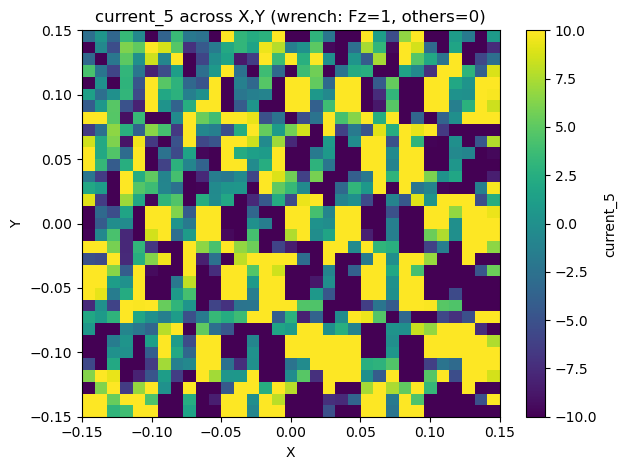

In [10]:
# filter to the fixed input wrench: Fx=Fy=Tx=Ty=Tz=0, Fz=1
w_cols = ['wrench_Fx','wrench_Fy','wrench_Fz','wrench_Tx','wrench_Ty','wrench_Tz']
df_ = df[(df['wrench_Fx']==1)&(df['wrench_Fy']==0)&(df['wrench_Fz']==0)&
         (df['wrench_Tx']==0)&(df['wrench_Ty']==0)&(df['wrench_Tz']==0)].copy()

# drop/ignore wrench_out*
df_ = df_.drop(columns=[c for c in df_.columns if c.startswith('wrench_out_')], errors='ignore')

# keep other things fixed: pick one unique value for every non-(X,Y,current_*,wrench_*) column
fixed_candidates = [
    c for c in df_.columns
    if c not in ['X','Y','current_1'] and not c.startswith('current_') and not c.startswith('wrench_')
]
for c in fixed_candidates:
    vals = df_[c].dropna().unique()
    if len(vals) > 0:
        df_ = df_[df_[c] == vals[0]]

# make a grid of current_1 over X,Y
grid = df_.pivot_table(index='Y', columns='X', values='current_16', aggfunc='mean')
grid = grid.sort_index().sort_index(axis=1)

# plot
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(
    grid.values, origin='lower', aspect='auto',
    extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
)
plt.colorbar(label='current_5')
plt.xlabel('X'); plt.ylabel('Y')
plt.title('current_5 across X,Y (wrench: Fz=1, others=0)')
plt.tight_layout()


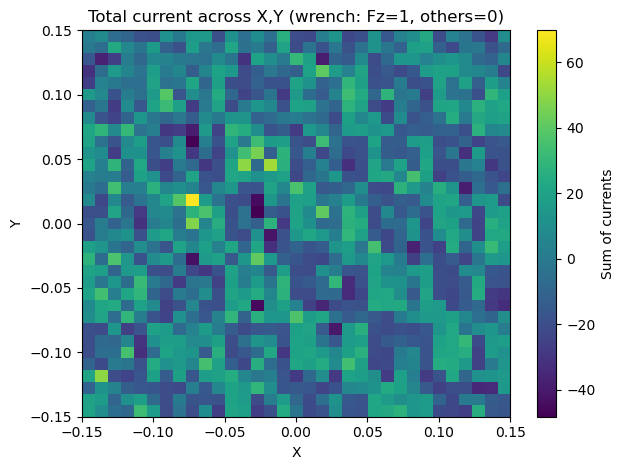

In [11]:
# sum all currents
current_cols = [c for c in df_.columns if c.startswith('current_')]
df_['current_sum'] = df_[current_cols].sum(axis=1)

# make grid over X,Y for the sum
grid = df_.pivot_table(index='Y', columns='X', values='current_sum', aggfunc='mean')
grid = grid.sort_index().sort_index(axis=1)

# plot
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(
    grid.values, origin='lower', aspect='auto',
    extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
)
plt.colorbar(label='Sum of currents')
plt.xlabel('X'); plt.ylabel('Y')
plt.title('Total current across X,Y (wrench: Fz=1, others=0)')
plt.tight_layout()

### Currents dependancy on angles analysis

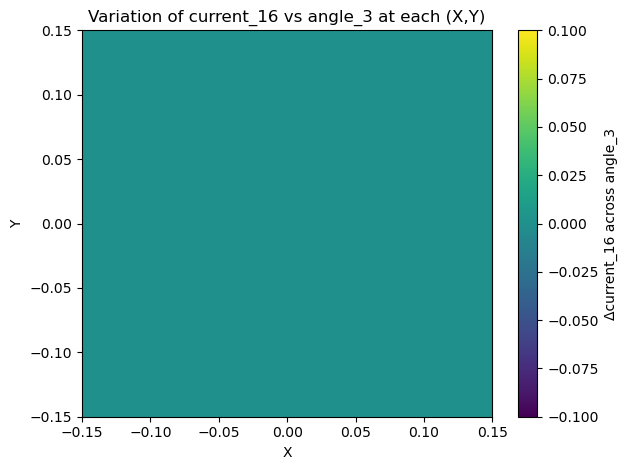

In [12]:
# keep angle_3 free; fix everything else (angles 1&2 fixed)
fixed_cols = [
    c for c in df_.columns
    if c not in ['X','Y','angle_1'] and not c.startswith('current_') and not c.startswith('wrench_')
]
for c in fixed_cols:
    vals = df_[c].dropna().unique()
    if len(vals): df_ = df_[df_[c] == vals[0]]

# ---- choose what to measure ----
# (A) total current variation across angle_3
current_cols = [c for c in df_.columns if c.startswith('current_')]
df_['current_sum'] = df_[current_cols].sum(axis=1)
target = 'current_sum'

# # (B) single coil instead (uncomment to use)
target = 'current_16'

# range (max - min) over angle_3 at each (X,Y)
delta_xy = (df_.groupby(['X','Y'])[target]
              .agg(lambda s: s.max() - s.min())
              .reset_index(name='delta'))

# heatmap
grid = delta_xy.pivot(index='Y', columns='X', values='delta').sort_index().sort_index(axis=1)

import matplotlib.pyplot as plt
plt.figure()
plt.imshow(
    grid.values, origin='lower', aspect='auto',
    extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
)
plt.colorbar(label=f'Δ{target} across angle_3')
plt.xlabel('X'); plt.ylabel('Y')
plt.title(f'Variation of {target} vs angle_3 at each (X,Y)')
plt.tight_layout()


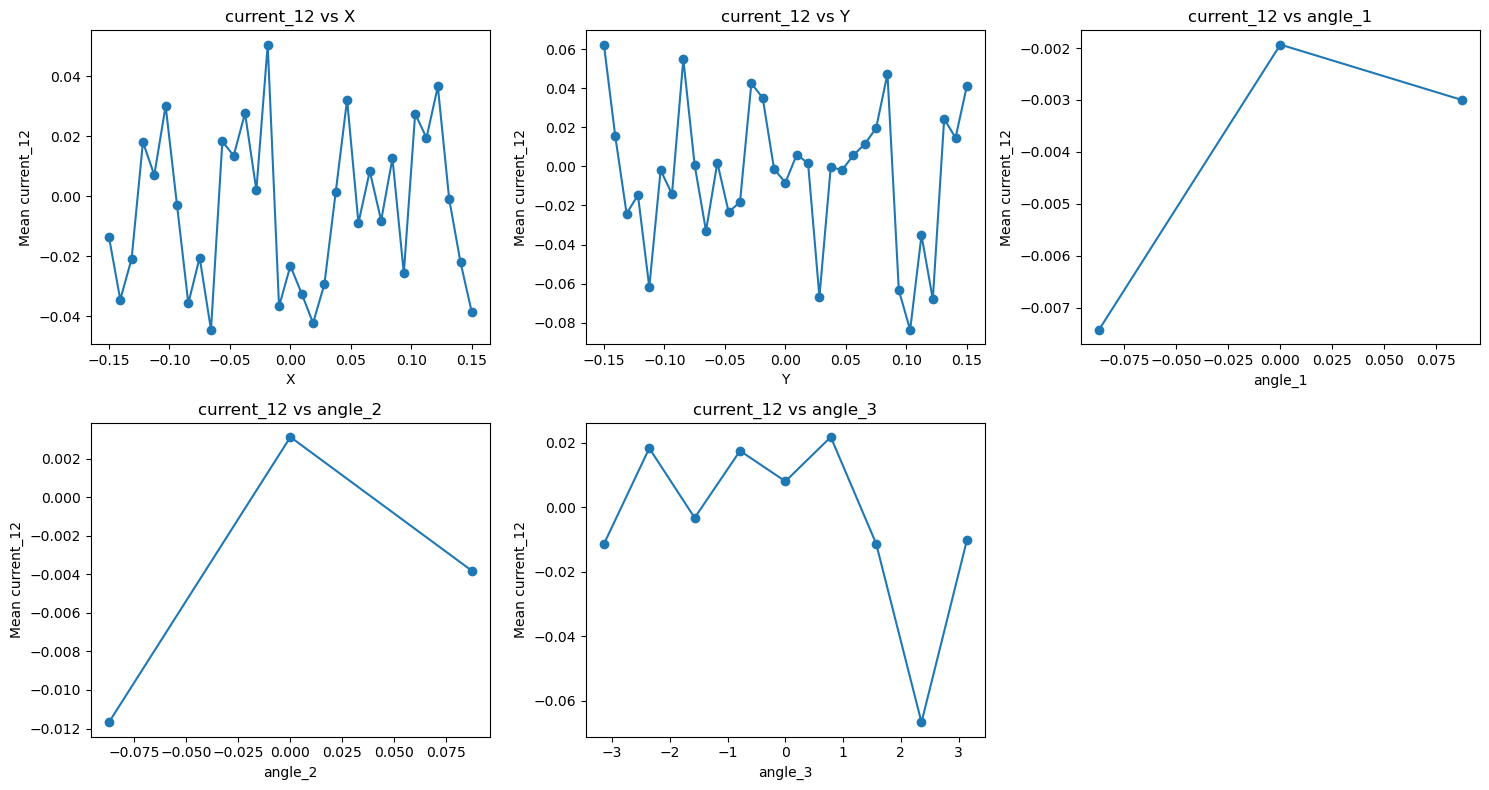

In [13]:
import matplotlib.pyplot as plt

target = 'current_12'  # change to current_5 or others if you want

vars_to_check = ['X', 'Y', 'angle_1', 'angle_2', 'angle_3']

plt.figure(figsize=(15, 8))

for i, var in enumerate(vars_to_check, 1):
    mean_vals = df.groupby(var)[target].mean().reset_index()
    plt.subplot(2, 3, i)
    plt.plot(mean_vals[var], mean_vals[target], marker='o')
    plt.xlabel(var)
    plt.ylabel(f"Mean {target}")
    plt.title(f"{target} vs {var}")

plt.tight_layout()
plt.show()


### Current values over dataset samples

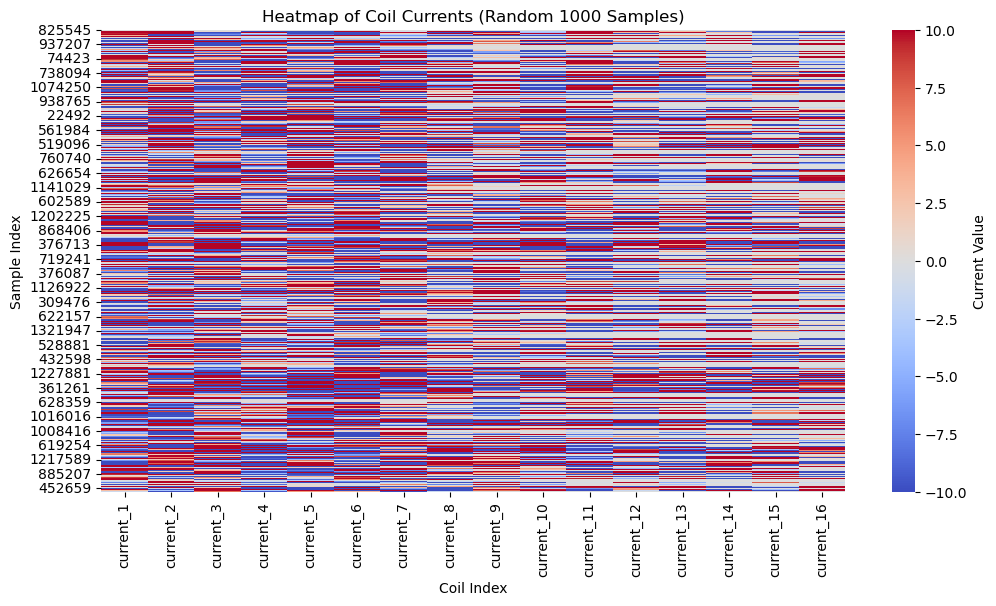

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Pick 1000 random samples
curr_cols = [c for c in df.columns if c.startswith('current_')]
rand_idx = np.random.choice(df.index, size=1000, replace=False)
currents_subset = df.loc[rand_idx, curr_cols]

plt.figure(figsize=(12, 6))
sns.heatmap(currents_subset, cmap='coolwarm', center=0, cbar_kws={'label': 'Current Value'})
plt.xlabel('Coil Index')
plt.ylabel('Sample Index')
plt.title('Heatmap of Coil Currents (Random 1000 Samples)')
plt.show()


### Frequency Analysis of currents over X-Y Plane

Visualize for one coil as an example

Dominant spatial frequency vector: (9.6970, -9.6970)
Dominant wavelength: 0.0729 units
Orientation of bands: -45.00 degrees


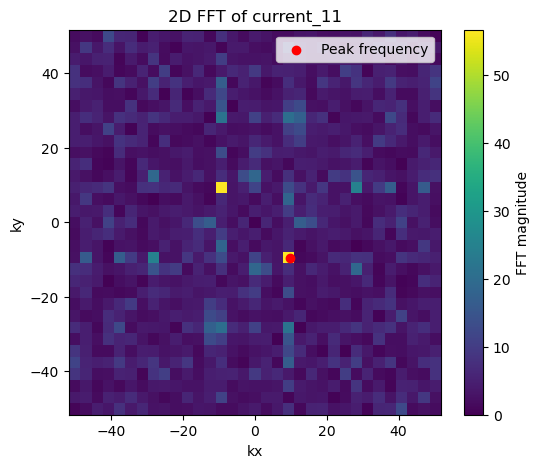

In [15]:
import numpy as np
import matplotlib.pyplot as plt

target = 'current_11'  # change if you want another coil

# Pivot into a 2D grid
grid = df.pivot_table(index='Y', columns='X', values=target, aggfunc='mean')
grid = grid.sort_index().sort_index(axis=1)  # sort axes

# Coordinates
X_coords = grid.columns.to_numpy()
Y_coords = grid.index.to_numpy()

# FFT
F = np.fft.fftshift(np.fft.fft2(grid.fillna(0).to_numpy()))
F_mag = np.abs(F)

# Find dominant frequency (ignore DC component)
center = tuple(np.array(F_mag.shape) // 2)
F_mag[center] = 0
peak_idx = np.unravel_index(np.argmax(F_mag), F_mag.shape)

# Frequency steps
dx = X_coords[1] - X_coords[0]
dy = Y_coords[1] - Y_coords[0]
kx = np.fft.fftshift(np.fft.fftfreq(len(X_coords), d=dx))
ky = np.fft.fftshift(np.fft.fftfreq(len(Y_coords), d=dy))

peak_kx = kx[peak_idx[1]]
peak_ky = ky[peak_idx[0]]

# Wavelength & orientation
wavelength = 1 / np.sqrt(peak_kx**2 + peak_ky**2)
orientation_deg = np.degrees(np.arctan2(peak_ky, peak_kx))

print(f"Dominant spatial frequency vector: ({peak_kx:.4f}, {peak_ky:.4f})")
print(f"Dominant wavelength: {wavelength:.4f} units")
print(f"Orientation of bands: {orientation_deg:.2f} degrees")

# Plot FFT magnitude
plt.figure(figsize=(6,5))
plt.imshow(F_mag, extent=[kx.min(), kx.max(), ky.min(), ky.max()], origin='lower', aspect='auto')
plt.colorbar(label='FFT magnitude')
plt.scatter([peak_kx], [peak_ky], color='red', label='Peak frequency')
plt.xlabel('kx')
plt.ylabel('ky')
plt.title(f'2D FFT of {target}')
plt.legend()
plt.show()


The report of FFt for all coils

In [16]:
import numpy as np
import pandas as pd

def fft_xy_params_for_all_coils(df, current_prefix='current_'):
    results = []
    Xs = np.sort(df['X'].unique())
    Ys = np.sort(df['Y'].unique())
    dx = np.diff(Xs).mean()
    dy = np.diff(Ys).mean()
    kx = np.fft.fftshift(np.fft.fftfreq(len(Xs), d=dx))
    ky = np.fft.fftshift(np.fft.fftfreq(len(Ys), d=dy))

    for col in [c for c in df.columns if c.startswith(current_prefix)]:
        grid = (df.pivot_table(index='Y', columns='X', values=col, aggfunc='mean')
                  .reindex(index=Ys, columns=Xs))
        A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()

        F = np.fft.fftshift(np.fft.fft2(A))
        M = np.abs(F)
        cy, cx = np.array(M.shape)//2
        M[cy, cx] = 0  # drop DC
        py, px = np.unravel_index(np.argmax(M), M.shape)

        kx_peak = kx[px]
        ky_peak = ky[py]
        k_mag = np.hypot(kx_peak, ky_peak)
        wavelength = 1.0/k_mag if k_mag > 0 else np.nan

        k_angle_deg = np.degrees(np.arctan2(ky_peak, kx_peak))            # wavevector angle
        bands_angle_deg = (k_angle_deg + 90.0 + 180.0) % 180.0            # stripe orientation

        results.append({
            'coil': col,
            'kx': kx_peak,
            'ky': ky_peak,
            'k_mag': k_mag,
            'wavelength': wavelength,
            'k_angle_deg': k_angle_deg,
            'bands_angle_deg': bands_angle_deg
        })

    return pd.DataFrame(results).sort_values('coil').reset_index(drop=True)

# usage:
params_df = fft_xy_params_for_all_coils(df)
print(params_df)


/tmp/ipykernel_160929/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_160929/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_160929/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_160929/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffil

          coil         kx         ky      k_mag  wavelength  k_angle_deg  \
0    current_1   9.696970  -9.696970  13.713586    0.072920   -45.000000   
1   current_10   9.696970  -9.696970  13.713586    0.072920   -45.000000   
2   current_11   9.696970  -9.696970  13.713586    0.072920   -45.000000   
3   current_12   9.696970  -9.696970  13.713586    0.072920   -45.000000   
4   current_13  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
5   current_14   9.696970  -9.696970  13.713586    0.072920   -45.000000   
6   current_15  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
7   current_16  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
8    current_2  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
9    current_3  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
10   current_4  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
11   current_5 -42.020202 -51.717172  66.636051    0.015007  -129.093859   
12   current

/tmp/ipykernel_160929/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_160929/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_160929/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_160929/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffil

# Feature Extraction

In [17]:
df.head()

,X,Y,Z,angle_1,angle_2,angle_3,wrench_Fx,wrench_Fy,wrench_Fz,wrench_Tx,...,current_7,current_8,current_9,current_10,current_11,current_12,current_13,current_14,current_15,current_16
0,-0.150000,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-4.312420,-10.000000,10.000000,9.380868,-10.000000,10.000000,-10.000000,10.000000,10.000000
1,-0.140625,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-6.186670,-10.000000,10.000000,5.427733,-10.000000,10.000000,-10.000000,3.694898,10.000000
2,-0.131250,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,10.000000,9.186635,-5.858047,10.000000,-0.703584,-1.272686,-0.492354,0.891581,-1.653864,3.078829
3,-0.121875,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-10.000000,-10.000000,9.134971,10.000000,-1.060216,10.000000,-5.549140,-10.000000,3.863199
4,-0.112500,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,1.232469,-2.340074,-10.000000,10.000000,10.000000,-10.000000,10.000000,-10.000000,5.231467,10.000000


In [18]:
df.columns

Index(['X', 'Y', 'Z', 'angle_1', 'angle_2', 'angle_3', 'wrench_Fx',
       'wrench_Fy', 'wrench_Fz', 'wrench_Tx', 'wrench_Ty', 'wrench_Tz',
       'wrench_out_Fx', 'wrench_out_Fy', 'wrench_out_Fz', 'wrench_out_Tx',
       'wrench_out_Ty', 'wrench_out_Tz', 'current_1', 'current_2', 'current_3',
       'current_4', 'current_5', 'current_6', 'current_7', 'current_8',
       'current_9', 'current_10', 'current_11', 'current_12', 'current_13',
       'current_14', 'current_15', 'current_16'],
      dtype='object')

## Phase1: 

### Drop unnecessary columns

drop wrench_out

In [19]:
# Drop columns containing 'wrench_out' in their name
df = df.drop(columns=[col for col in df.columns if 'wrench_out' in col])


In [20]:
df.columns

Index(['X', 'Y', 'Z', 'angle_1', 'angle_2', 'angle_3', 'wrench_Fx',
       'wrench_Fy', 'wrench_Fz', 'wrench_Tx', 'wrench_Ty', 'wrench_Tz',
       'current_1', 'current_2', 'current_3', 'current_4', 'current_5',
       'current_6', 'current_7', 'current_8', 'current_9', 'current_10',
       'current_11', 'current_12', 'current_13', 'current_14', 'current_15',
       'current_16'],
      dtype='object')

In [21]:
df.head()

,X,Y,Z,angle_1,angle_2,angle_3,wrench_Fx,wrench_Fy,wrench_Fz,wrench_Tx,...,current_7,current_8,current_9,current_10,current_11,current_12,current_13,current_14,current_15,current_16
0,-0.150000,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-4.312420,-10.000000,10.000000,9.380868,-10.000000,10.000000,-10.000000,10.000000,10.000000
1,-0.140625,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-6.186670,-10.000000,10.000000,5.427733,-10.000000,10.000000,-10.000000,3.694898,10.000000
2,-0.131250,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,10.000000,9.186635,-5.858047,10.000000,-0.703584,-1.272686,-0.492354,0.891581,-1.653864,3.078829
3,-0.121875,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-10.000000,-10.000000,9.134971,10.000000,-1.060216,10.000000,-5.549140,-10.000000,3.863199
4,-0.112500,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,1.232469,-2.340074,-10.000000,10.000000,10.000000,-10.000000,10.000000,-10.000000,5.231467,10.000000


In [22]:
df.columns

Index(['X', 'Y', 'Z', 'angle_1', 'angle_2', 'angle_3', 'wrench_Fx',
       'wrench_Fy', 'wrench_Fz', 'wrench_Tx', 'wrench_Ty', 'wrench_Tz',
       'current_1', 'current_2', 'current_3', 'current_4', 'current_5',
       'current_6', 'current_7', 'current_8', 'current_9', 'current_10',
       'current_11', 'current_12', 'current_13', 'current_14', 'current_15',
       'current_16'],
      dtype='object')

### Drop current outliers

In [23]:
# Step 4 — Drop rows with any |current| > 10
def drop_current_outliers(df, current_cols, threshold=10.0):
    import pandas as pd  # remove if already imported

    abs_curr = df.loc[:, current_cols].apply(pd.to_numeric, errors="coerce").abs()
    too_big = abs_curr.gt(threshold).any(axis=1).fillna(False)
    dropped_mask = too_big.reindex(df.index, fill_value=False)
    df_clean = df.loc[~too_big].copy()

    return df_clean, dropped_mask

# Filter to existing current columns
valid_current_cols = [c for c in current_cols if c in df.columns]

df, dropped_mask = drop_current_outliers(
    df,
    current_cols=valid_current_cols,
    threshold=10.0
)


In [24]:
df.head

<bound method NDFrame.head of                 X     Y      Z   angle_1   angle_2   angle_3  wrench_Fx  \
0       -0.150000 -0.15  0.005 -0.087266 -0.087266 -3.141593   1.000000   
1       -0.140625 -0.15  0.005 -0.087266 -0.087266 -3.141593   1.000000   
2       -0.131250 -0.15  0.005 -0.087266 -0.087266 -3.141593   1.000000   
3       -0.121875 -0.15  0.005 -0.087266 -0.087266 -3.141593   1.000000   
4       -0.112500 -0.15  0.005 -0.087266 -0.087266 -3.141593   1.000000   
...           ...   ...    ...       ...       ...       ...        ...   
1411337  0.093750  0.15  0.005  0.087266  0.087266  3.141593 -13.381404   
1411339  0.112500  0.15  0.005  0.087266  0.087266  3.141593 -13.381404   
1411341  0.131250  0.15  0.005  0.087266  0.087266  3.141593 -13.381404   
1411342  0.140625  0.15  0.005  0.087266  0.087266  3.141593 -13.381404   
1411343  0.150000  0.15  0.005  0.087266  0.087266  3.141593 -13.381404   

         wrench_Fy  wrench_Fz  wrench_Tx  ...  current_7  current_8  

# Input-Target Definition

## Current Kmeans

In [25]:
import re

# Detect current columns
current_cols = sorted(
    [c for c in df.columns if c.startswith("current_") and re.search(r"\d+$", c)],
    key=lambda x: int(re.search(r"\d+", x).group())
)

In [26]:
from sklearn.cluster import KMeans
import numpy as np

# Collect all current values across the 16 signals
X_vals = df[current_cols].values.reshape(-1, 1)   # stack into one column

# Run KMeans with, say, 3 or 5 clusters (you can tune this)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(X_vals)

# Get cluster centers sorted left→right
centers = np.sort(kmeans.cluster_centers_.ravel())

# Map each current column into cluster labels
for c in current_cols:
    labels = kmeans.predict(df[c].values.reshape(-1, 1))
    # reorder labels so that 0=lowest center, ..., k-1=highest center
    mapping = {old: new for new, old in enumerate(np.argsort(kmeans.cluster_centers_.ravel()))}
    df[f"{c}_cls"] = [mapping[l] for l in labels]

# Optionally drop original continuous current values
df.drop(columns=current_cols, inplace=True)

# Track class columns
class_cols = sorted(
    [c for c in df.columns if c.startswith("current_") and c.endswith("_cls")],
    key=lambda x: int(re.search(r"\d+", x).group())
)

print("Cluster centers:", centers)


Cluster centers: [-9.50281370e+00 -3.58893830e-03  9.49622068e+00]


In [27]:
df.columns

Index(['X', 'Y', 'Z', 'angle_1', 'angle_2', 'angle_3', 'wrench_Fx',
       'wrench_Fy', 'wrench_Fz', 'wrench_Tx', 'wrench_Ty', 'wrench_Tz',
       'current_1_cls', 'current_2_cls', 'current_3_cls', 'current_4_cls',
       'current_5_cls', 'current_6_cls', 'current_7_cls', 'current_8_cls',
       'current_9_cls', 'current_10_cls', 'current_11_cls', 'current_12_cls',
       'current_13_cls', 'current_14_cls', 'current_15_cls', 'current_16_cls'],
      dtype='object')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


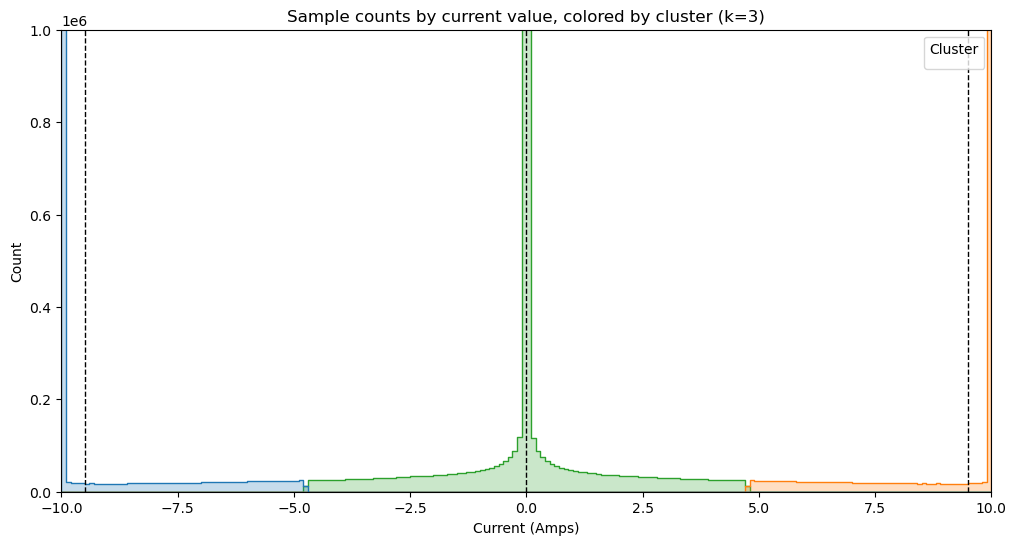

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Recompute labels for all stacked values so we can pair with X_vals
all_labels = kmeans.predict(X_vals)

plt.figure(figsize=(12,6))
sns.histplot(
    x=X_vals.ravel(), 
    hue=all_labels, 
    bins=200, 
    palette="tab10", 
    element="step", 
    stat="count"
)

# Mark cluster centers
for c in centers:
    plt.axvline(c, color="black", linestyle="--", linewidth=1)

plt.xlim(-10, 10)
plt.ylim(0, 1000000)
plt.title(f"Sample counts by current value, colored by cluster (k={n_clusters})")
plt.xlabel("Current (Amps)")
plt.ylabel("Count")
plt.legend(title="Cluster")
plt.show()


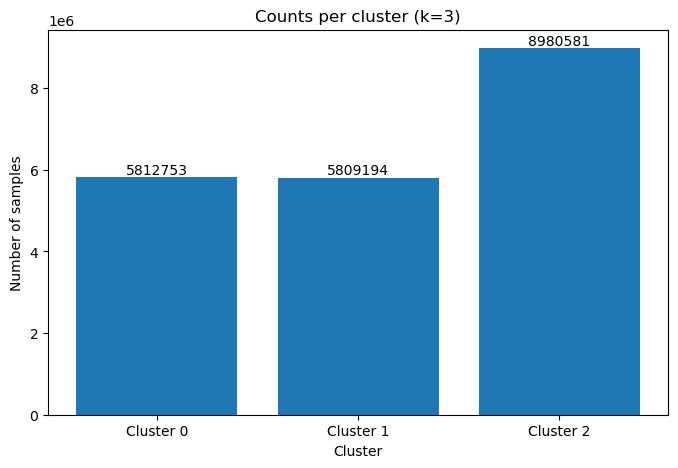

In [29]:
# Count how many samples per cluster
import numpy as np
import matplotlib.pyplot as plt

unique, counts = np.unique(all_labels, return_counts=True)

plt.figure(figsize=(8,5))
plt.bar(unique, counts, color="C0")

# Annotate bars with counts
for i, c in zip(unique, counts):
    plt.text(i, c, str(c), ha="center", va="bottom")

plt.xticks(unique, [f"Cluster {i}" for i in unique])
plt.xlabel("Cluster")
plt.ylabel("Number of samples")
plt.title(f"Counts per cluster (k={n_clusters})")
plt.show()


In [30]:
for k in range(n_clusters):
    cluster_vals = X_vals[all_labels == k]
    print(f"Cluster {k}: count={len(cluster_vals)}, "
          f"min={cluster_vals.min():.2f}, max={cluster_vals.max():.2f}, "
          f"mean={cluster_vals.mean():.2f}, std={cluster_vals.std():.2f}")


Cluster 0: count=5812753, min=-10.00, max=-4.75, mean=-9.50, std=1.25
Cluster 1: count=5809194, min=4.75, max=10.00, mean=9.50, std=1.25
Cluster 2: count=8980581, min=-4.75, max=4.75, mean=-0.00, std=1.51


In [31]:
df.columns

Index(['X', 'Y', 'Z', 'angle_1', 'angle_2', 'angle_3', 'wrench_Fx',
       'wrench_Fy', 'wrench_Fz', 'wrench_Tx', 'wrench_Ty', 'wrench_Tz',
       'current_1_cls', 'current_2_cls', 'current_3_cls', 'current_4_cls',
       'current_5_cls', 'current_6_cls', 'current_7_cls', 'current_8_cls',
       'current_9_cls', 'current_10_cls', 'current_11_cls', 'current_12_cls',
       'current_13_cls', 'current_14_cls', 'current_15_cls', 'current_16_cls'],
      dtype='object')

In [32]:
# Shuffle the dataframe for randomness
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

import re
import pandas as pd

# --- Canonical sets ---
WRENCH_COLS = ["wrench_Fx","wrench_Fy","wrench_Fz",
               "wrench_Tx","wrench_Ty","wrench_Tz"]

# Current target columns (numeric order)
current_cols = sorted(
    [c for c in df.columns if c.startswith("current_")],
    key=lambda x: int(re.search(r"\d+", x).group())
)

# Feature columns = everything else (not wrench, not current)
feature_cols = [c for c in df.columns 
                if c not in set(WRENCH_COLS + current_cols)]

# --- Build blocks ---
X_feat = df.loc[:, feature_cols].apply(pd.to_numeric, errors="coerce").copy()
W      = df.loc[:, WRENCH_COLS].apply(pd.to_numeric, errors="coerce").copy()
I      = df.loc[:, current_cols].apply(pd.to_numeric, errors="coerce").copy()


In [33]:
X_feat.head()

,X,Y,Z,angle_1,angle_2,angle_3
0,-0.0750,-0.046875,0.005,-0.087266,-0.087266,-2.356194
1,-0.0375,-0.112500,0.005,0.000000,-0.087266,-0.785398
2,0.0375,-0.018750,0.005,-0.087266,0.087266,-0.785398
3,-0.1125,0.028125,0.005,-0.087266,0.000000,0.785398
4,-0.0750,0.131250,0.005,0.087266,0.087266,-2.356194


In [34]:
W.head()

,wrench_Fx,wrench_Fy,wrench_Fz,wrench_Tx,wrench_Ty,wrench_Tz
0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
1,20.506213,41.769258,1.979486,0.600467,3.603379,0.094274
2,-22.372319,3.787195,60.733533,3.060779,-4.956699,2.929608
3,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
4,20.506213,41.769258,1.979486,0.600467,3.603379,0.094274


In [35]:
I.head()

,current_1_cls,current_2_cls,current_3_cls,current_4_cls,current_5_cls,current_6_cls,current_7_cls,current_8_cls,current_9_cls,current_10_cls,current_11_cls,current_12_cls,current_13_cls,current_14_cls,current_15_cls,current_16_cls
0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,2,2,1,2,2,1,0,1,1,1,1,1,1,1,1,1
2,1,1,0,2,1,0,2,1,1,1,1,1,1,1,1,1
3,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1
4,0,0,0,2,2,2,0,2,1,1,1,2,0,2,1,1


# PCA on currents

In [36]:
I.head()

,current_1_cls,current_2_cls,current_3_cls,current_4_cls,current_5_cls,current_6_cls,current_7_cls,current_8_cls,current_9_cls,current_10_cls,current_11_cls,current_12_cls,current_13_cls,current_14_cls,current_15_cls,current_16_cls
0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,2,2,1,2,2,1,0,1,1,1,1,1,1,1,1,1
2,1,1,0,2,1,0,2,1,1,1,1,1,1,1,1,1
3,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1
4,0,0,0,2,2,2,0,2,1,1,1,2,0,2,1,1


In [41]:
I.columns

Index(['current_1_cls', 'current_2_cls', 'current_3_cls', 'current_4_cls',
       'current_5_cls', 'current_6_cls', 'current_7_cls', 'current_8_cls',
       'current_9_cls', 'current_10_cls', 'current_11_cls', 'current_12_cls',
       'current_13_cls', 'current_14_cls', 'current_15_cls', 'current_16_cls'],
      dtype='object')

In [36]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from scipy import sparse

# one-hot encode the dataframe
enc = OneHotEncoder(sparse_output=True, dtype=np.float32)  # sparse to save RAM
X_encoded = enc.fit_transform(I)

print(f"Encoded shape: {X_encoded.shape}, sparse={sparse.issparse(X_encoded)}")


Encoded shape: (1287658, 48), sparse=True


In [37]:
from sklearn.decomposition import TruncatedSVD

# compress to ~40 components (safe since you only had 48 one-hot cols)
svd = TruncatedSVD(n_components=40, random_state=42)
X_svd = svd.fit_transform(X_encoded).astype(np.float32)

print("SVD reduced shape:", X_svd.shape)


SVD reduced shape: (1287658, 40)


In [38]:
import umap.umap_ as umap

# Subsample before SVD/UMAP
frac = 0.5
n_sub = int(frac * X_encoded.shape[0])
idx = np.random.choice(X_encoded.shape[0], size=n_sub, replace=False)

X_sub = X_encoded[idx]
X_svd = svd.fit_transform(X_sub).astype(np.float32)

um_hi = umap.UMAP(n_components=10, n_neighbors=30, min_dist=0.05, random_state=42)
X_umap10 = um_hi.fit_transform(X_svd)


/home/alireza-linux/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/alireza-linux/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [45]:
Xc = X_umap10  # use the 10D UMAP embedding as clustering input


In [47]:
# FAST GMM: BIC on a small sample + diag cov, then final full fit

from sklearn.mixture import GaussianMixture
from sklearn.cluster import MiniBatchKMeans
import numpy as np

# ---- 1) small sample for BIC sweep ----
m = min(20000, len(Xc))
idx_bic = np.random.choice(len(Xc), size=m, replace=False)
Xc_bic = Xc[idx_bic].astype(np.float32)
Xc_bic = Xc_bic.astype(np.float64)


k_list = [8, 12, 16, 20]  # tighten sweep first; refine around the winner later
bic_log, models = [], {}

for k in k_list:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=4096, n_init=5)
    km.fit(Xc_bic)
    gmm_diag = GaussianMixture(
    n_components=k, covariance_type="diag",
    reg_covar=1e-4, max_iter=200, n_init=1, tol=1e-3,
    means_init=km.cluster_centers_, random_state=42
    ).fit(Xc_bic)
    bic = gmm_diag.bic(Xc_bic)
    bic_log.append((k, bic))
    models[k] = gmm_diag
    print(f"k={k}, BIC={bic:.2f}")

best_k, best_bic = min(bic_log, key=lambda t: t[1])
print(f"\nSelected k (sampled BIC) = {best_k}")

# ---- 2) final fit on ALL Xc (option A: diag, fast) ----
gmm = GaussianMixture(
    n_components=best_k, covariance_type="diag",
    reg_covar=1e-6, max_iter=300, n_init=2, tol=1e-3,
    means_init=models[best_k].means_, random_state=42, verbose=1
).fit(Xc.astype(np.float32))

# (option B: if you really want full cov, switch covariance_type="full" here;
# keep means_init from diag model to speed convergence.)

labels = gmm.predict(Xc)
proba  = gmm.predict_proba(Xc)
print(f"Done. k={best_k}, proba shape={proba.shape}")



k=8, BIC=595118.59
k=12, BIC=594255.31
k=16, BIC=565986.22
k=20, BIC=495822.52

Selected k (sampled BIC) = 20
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
Initialization converged.
Initialization 1
  Iteration 10
Initialization converged.
Done. k=20, proba shape=(643829, 20)


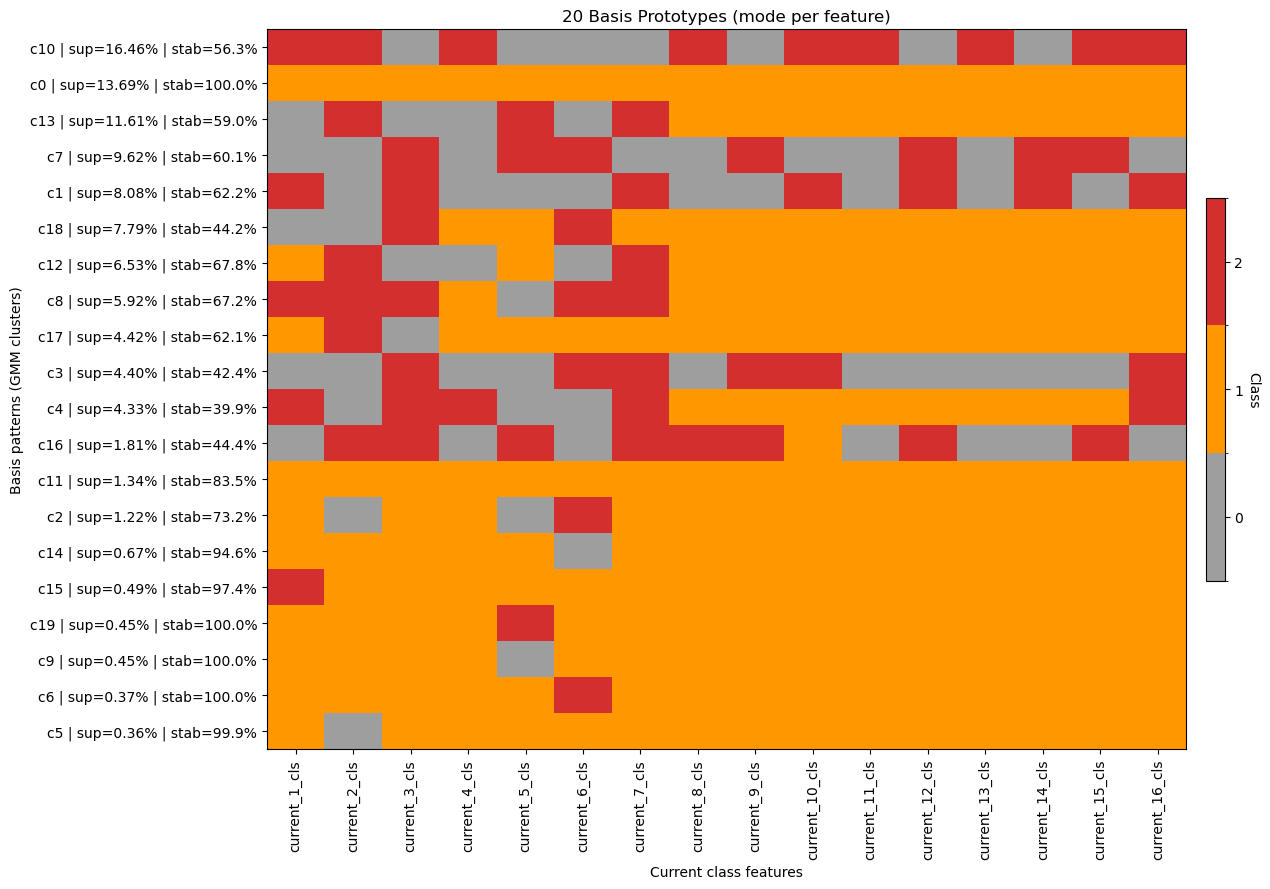

In [48]:
# === Build 20 basis patterns from GMM on your 0.5% subset ===
# Requires: I (original df), idx (indices of the 0.5% subset),
#           labels (shape [len(idx)]), proba (shape [len(idx), 20])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# 1) attach cluster labels to the subsample
I_sub = I.iloc[idx].copy()
I_sub["cluster"] = labels

# 2) prototype (mode) + stability (% of rows matching the mode) + support (%)
rows = []
for c in np.unique(labels):
    sub = I_sub[I_sub["cluster"] == c]
    sup = 100 * len(sub) / len(I_sub)
    for col in I.columns:
        mv = sub[col].mode()[0]
        stab = sub[col].value_counts(normalize=True).get(mv, 0.0) * 100
        rows.append({"cluster": int(c), "feature": col,
                     "proto_val": int(mv), "stability_%": round(stab, 1),
                     "support_%": round(sup, 2)})

catalog = pd.DataFrame(rows)

# 3) summary per cluster
summary = (catalog.groupby("cluster")["stability_%"].mean()
           .rename("avg_stability_%").to_frame()
           .join(catalog.groupby("cluster")["support_%"].first()))

# 4) pivot to matrix [clusters x features], sort clusters by support desc
feat_order = sorted(I.columns, key=lambda c: int(c.split("_")[1]))
order = summary.sort_values(["support_%","avg_stability_%"], ascending=[False, False]).index.tolist()

proto_mat = (catalog.pivot_table(index="cluster", columns="feature",
                                 values="proto_val", aggfunc="first")
             .reindex(index=order, columns=feat_order))

# 5) optional: export the basis as a compact dict
basis = {int(cid): proto_mat.loc[cid].astype(int).tolist() for cid in proto_mat.index}

# 6) heatmap (rows=basis patterns, cols=currents, color=class 0/1/2)
cmap = ListedColormap(["#9e9e9e", "#ff9800", "#d32f2f"])  # 0,1,2
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

row_labels = [f"c{int(cid)} | sup={summary.loc[cid,'support_%']:.2f}% | stab={summary.loc[cid,'avg_stability_%']:.1f}%"
              for cid in proto_mat.index]

fig, ax = plt.subplots(figsize=(0.55*proto_mat.shape[1] + 4, 0.35*proto_mat.shape[0] + 2))
im = ax.imshow(proto_mat.values, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
ax.set_xticks(np.arange(len(feat_order))); ax.set_xticklabels(feat_order, rotation=90)
ax.set_yticks(np.arange(len(row_labels))); ax.set_yticklabels(row_labels)

cbar = fig.colorbar(im, ax=ax, ticks=[0,1,2], fraction=0.02, pad=0.02)
cbar.set_label("Class", rotation=270, labelpad=12)

ax.set_xlabel("Current class features")
ax.set_ylabel("Basis patterns (GMM clusters)")
ax.set_title("20 Basis Prototypes (mode per feature)")

plt.tight_layout()
plt.show()

# 7) save the basis + summaries (so you can reuse without recomputing)
catalog.to_pickle("basis_catalog_gmm20.pkl")
summary.to_pickle("basis_summary_gmm20.pkl")
pd.DataFrame.from_dict(basis, orient="index").to_pickle("basis_vectors_gmm20.pkl")


In [49]:
# 1) Reload your saved GMM + UMAP if needed
# (assuming you still have `gmm` from before and `um_hi` the 10D UMAP)

from scipy import sparse
import pandas as pd

# --- Encode the whole dataframe I ---
enc = OneHotEncoder(sparse_output=True, dtype=np.float32)
X_encoded_full = enc.fit_transform(I)

# --- Reduce with the same SVD ---
svd_full = TruncatedSVD(n_components=40, random_state=42)
X_svd_full = svd_full.fit_transform(X_encoded_full).astype(np.float32)

# --- Transform with the UMAP fitted on subsample ---
X_umap10_full = um_hi.transform(X_svd_full)

# --- Predict with the GMM fitted on subsample ---
labels_full = gmm.predict(X_umap10_full)
proba_full  = gmm.predict_proba(X_umap10_full)

print("Full dataset assigned:", labels_full.shape, proba_full.shape)


/usr/lib/python3/dist-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


Full dataset assigned: (1287658,) (1287658, 20)


In [50]:
# Add hard cluster and soft weights
proba_cols = [f"pat_{i}" for i in range(proba_full.shape[1])]
I_with_patterns = pd.concat([
    I.reset_index(drop=True),
    pd.DataFrame(labels_full, columns=["cluster"]),
    pd.DataFrame(proba_full, columns=proba_cols)
], axis=1)

print(I_with_patterns.head())


   current_1_cls  current_2_cls  current_3_cls  current_4_cls  current_5_cls  \
0              1              1              1              1              1   
1              2              2              1              2              2   
2              1              1              0              2              1   
3              1              1              1              0              1   
4              0              0              0              2              2   

   current_6_cls  current_7_cls  current_8_cls  current_9_cls  current_10_cls  \
0              1              1              1              1               1   
1              1              0              1              1               1   
2              0              2              1              1               1   
3              1              1              1              1               1   
4              2              0              2              1               1   

   ...         pat_10         pa

In [52]:
I_with_patterns['cluster'].head()

0     0
1     8
2    12
3    11
4    13
Name: cluster, dtype: int64

In [54]:
I_with_patterns.to_pickle("I_with_patterns.pkl")


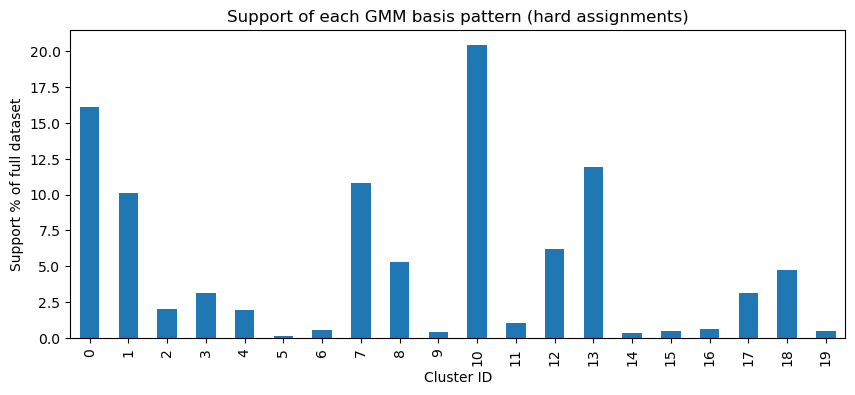

In [55]:
import matplotlib.pyplot as plt

cluster_counts = I_with_patterns["cluster"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(10,4))
cluster_counts.plot(kind="bar")
plt.ylabel("Support % of full dataset")
plt.xlabel("Cluster ID")
plt.title("Support of each GMM basis pattern (hard assignments)")
plt.show()


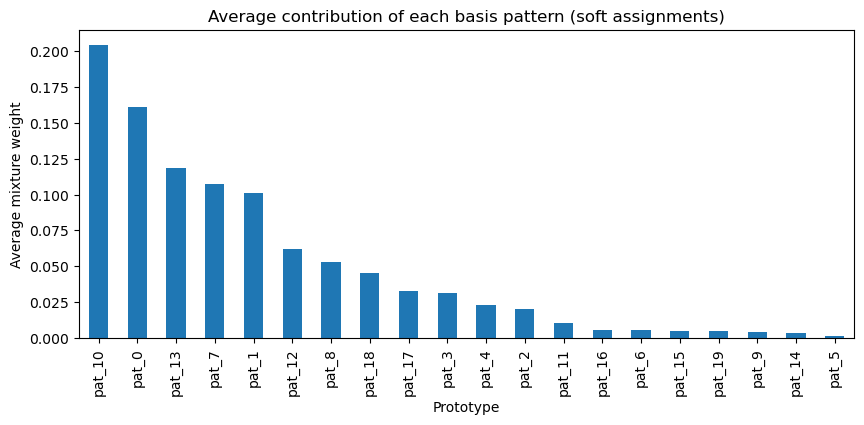

In [56]:
proba_cols = [c for c in I_with_patterns.columns if c.startswith("pat_")]

mean_weights = I_with_patterns[proba_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10,4))
mean_weights.plot(kind="bar")
plt.ylabel("Average mixture weight")
plt.xlabel("Prototype")
plt.title("Average contribution of each basis pattern (soft assignments)")
plt.show()


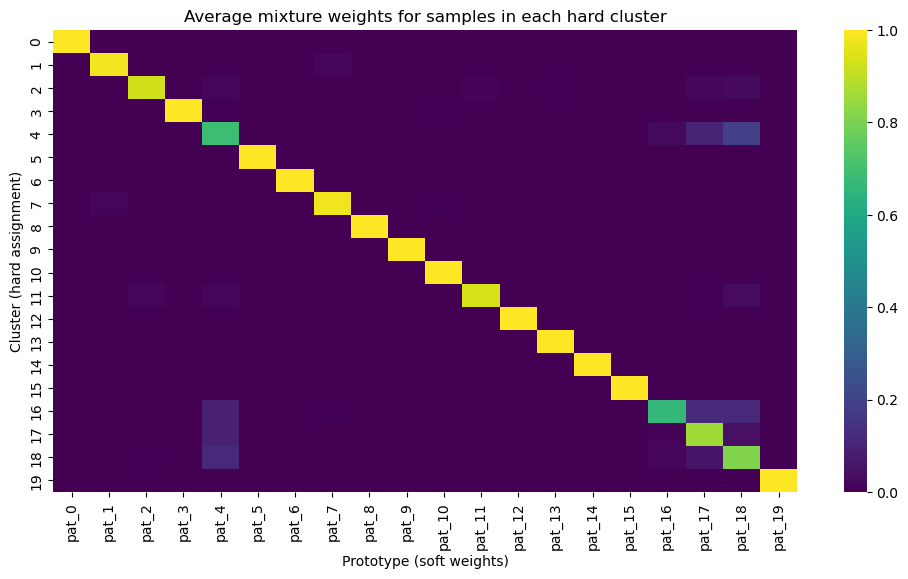

In [57]:
import seaborn as sns

avg_proba_per_cluster = I_with_patterns.groupby("cluster")[proba_cols].mean()

plt.figure(figsize=(12,6))
sns.heatmap(avg_proba_per_cluster, cmap="viridis", annot=False)
plt.title("Average mixture weights for samples in each hard cluster")
plt.xlabel("Prototype (soft weights)")
plt.ylabel("Cluster (hard assignment)")
plt.show()


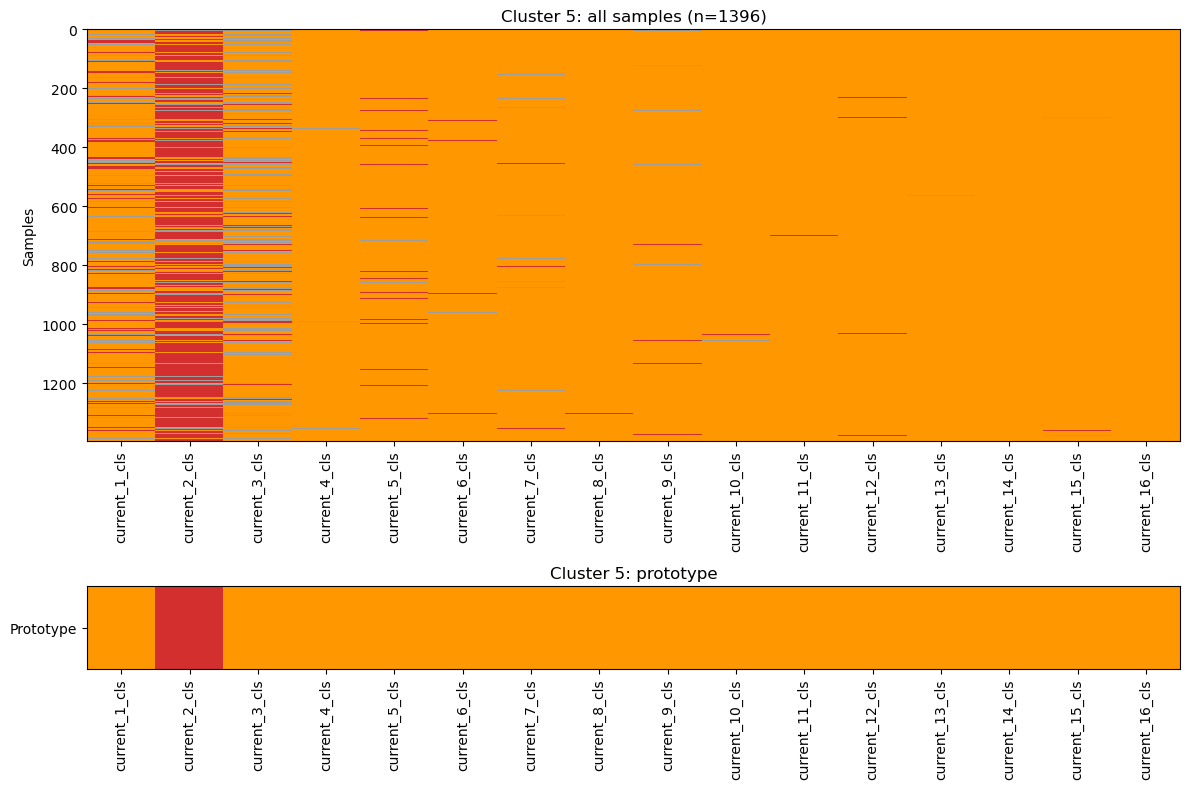

In [65]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

cluster_id = 5   # pick the cluster you want
feat_order = sorted([c for c in I_with_patterns.columns if c.startswith("current_")],
                    key=lambda c: int(c.split("_")[1]))

# subset rows belonging to that cluster
sub = I_with_patterns[I_with_patterns["cluster"] == cluster_id][feat_order].astype(int)

# prototype row
proto = sub.mode(dropna=False).iloc[0].values.reshape(1, -1)

# --- Plot ---
cmap = ListedColormap(["#9e9e9e", "#ff9800", "#d32f2f"])  # 0=gray, 1=orange, 2=red
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios":[5,1]})

# (A) all samples in cluster
axes[0].imshow(sub.values, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
axes[0].set_title(f"Cluster {cluster_id}: all samples (n={len(sub)})")
axes[0].set_xticks(range(len(feat_order)))
axes[0].set_xticklabels(feat_order, rotation=90)
axes[0].set_ylabel("Samples")

# (B) prototype (mode)
axes[1].imshow(proto, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
axes[1].set_xticks(range(len(feat_order)))
axes[1].set_xticklabels(feat_order, rotation=90)
axes[1].set_yticks([0]); axes[1].set_yticklabels(["Prototype"])
axes[1].set_title(f"Cluster {cluster_id}: prototype")

plt.tight_layout()
plt.show()


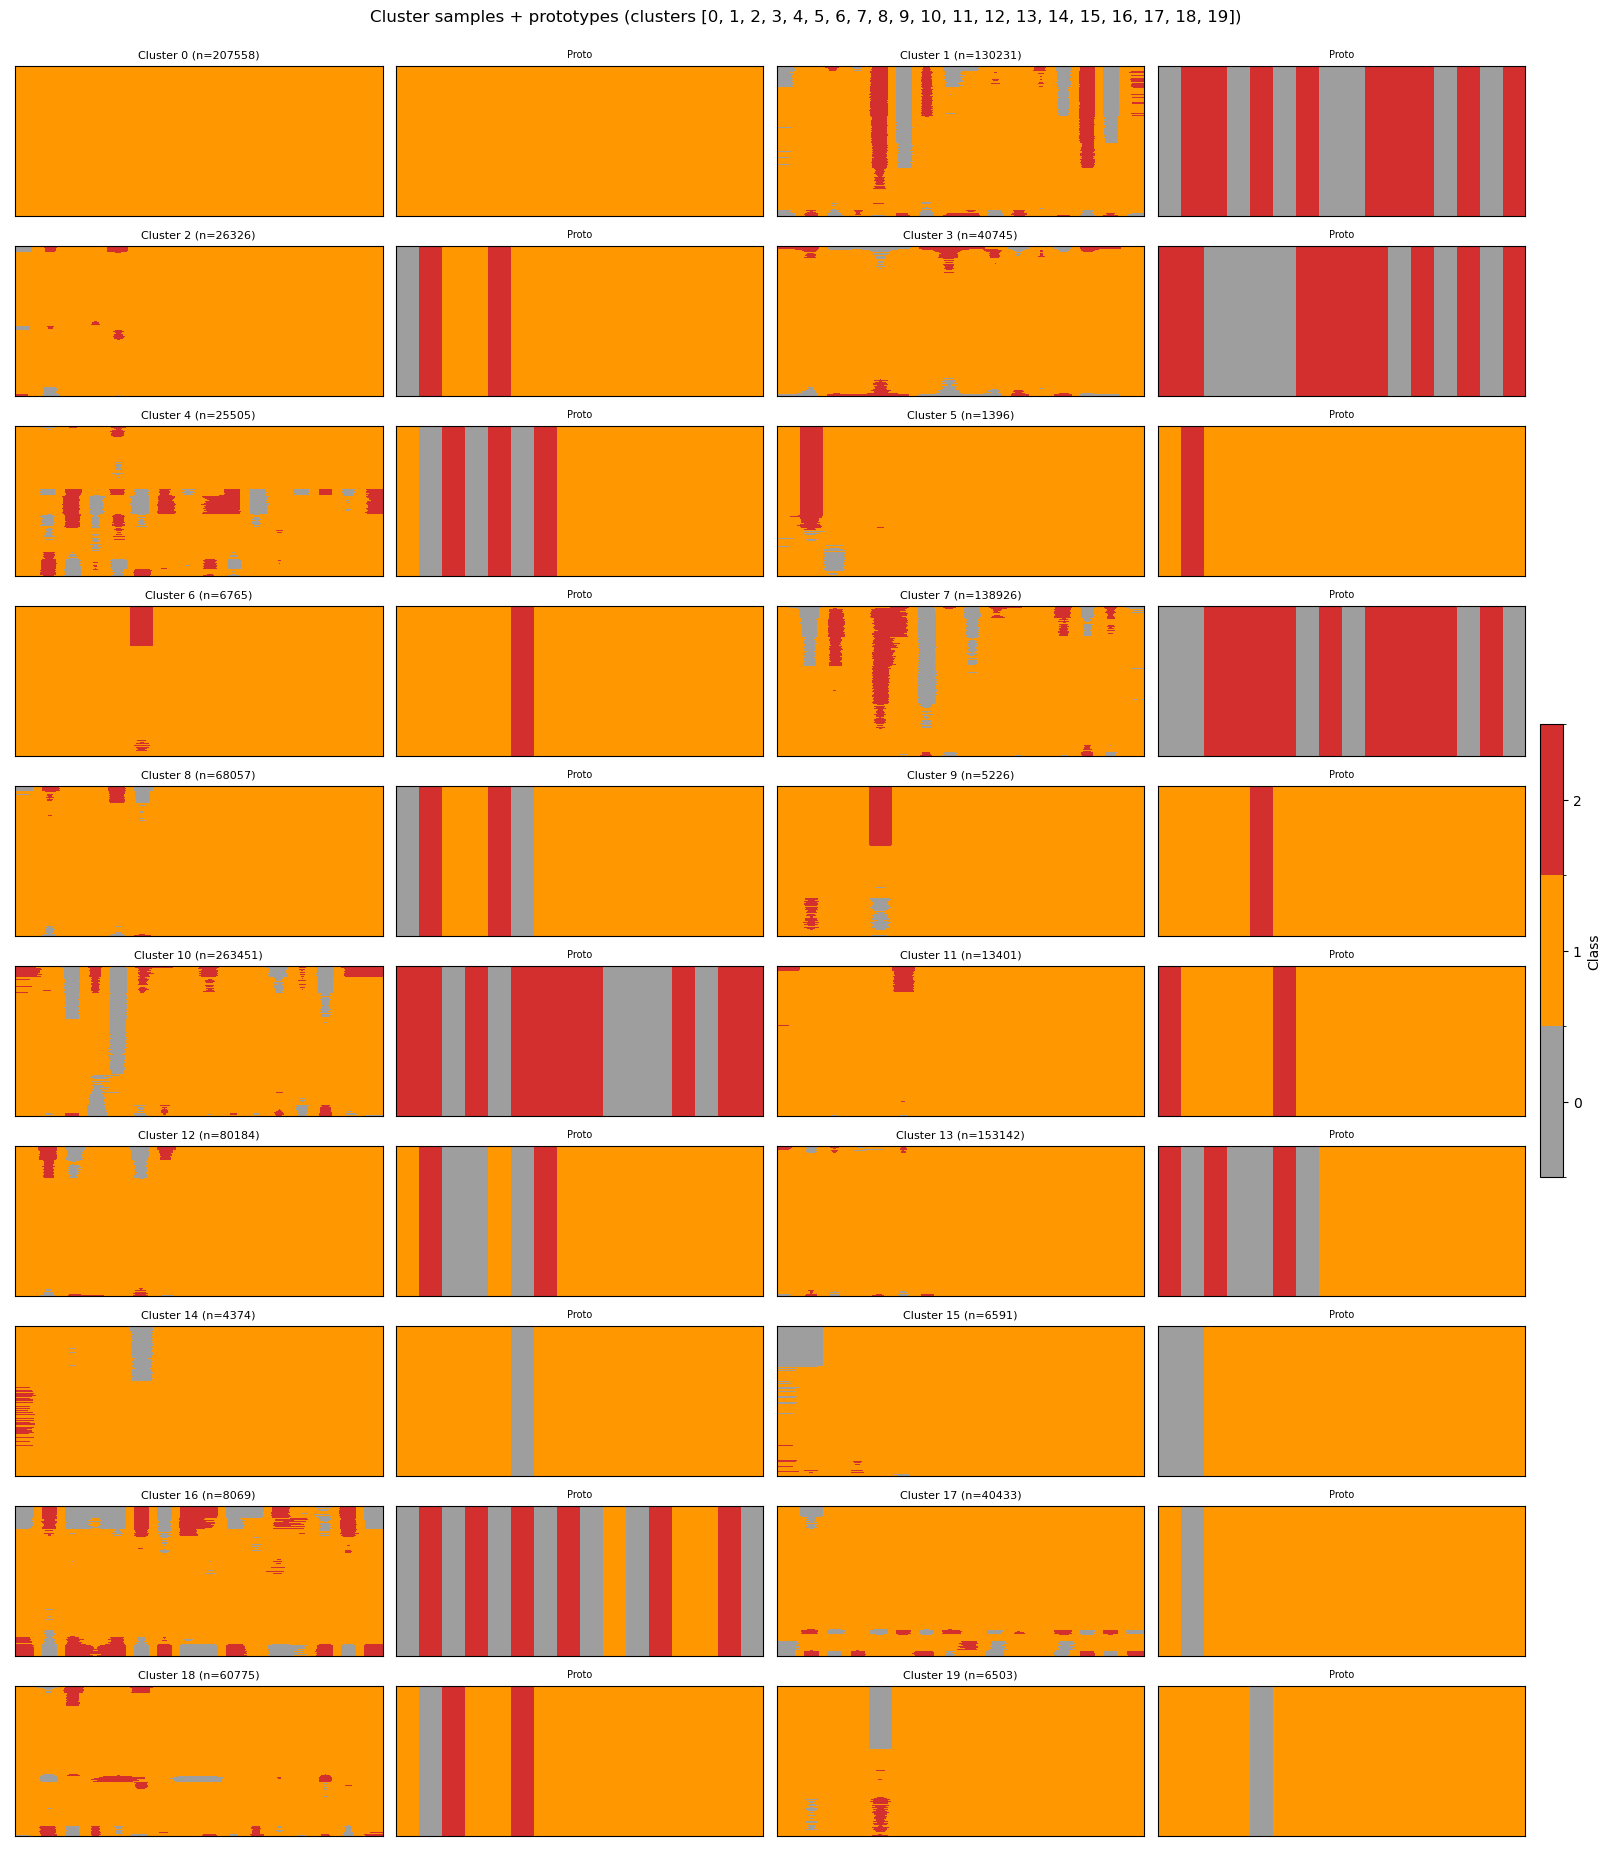

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# config
MAX_ROWS_PER_CLUSTER = 1000000  # cap rows per cluster for readability
GRID_ROWS, GRID_COLS = 5, 4  # 4x4 grid per page
SORT_BY_SIMILARITY = True

feat_order = sorted([c for c in I_with_patterns.columns if c.startswith("current_")],
                    key=lambda c: int(c.split("_")[1]))
clusters = sorted(I_with_patterns["cluster"].unique())

cmap = ListedColormap(["#9e9e9e", "#ff9800", "#d32f2f"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

def hamming(a, b):
    return (a != b).sum(axis=1)

# paginate over clusters
per_page = GRID_ROWS * GRID_COLS
for page_start in range(0, len(clusters), per_page):
    page_clusters = clusters[page_start:page_start+per_page]

    fig, axes = plt.subplots(GRID_ROWS*2, GRID_COLS, figsize=(4*GRID_COLS, 1.8*GRID_ROWS*2),
                             constrained_layout=True)
    axes = axes.ravel()

    last_im = None
    for j, cid in enumerate(page_clusters):
        sub = I_with_patterns[I_with_patterns["cluster"] == cid][feat_order].astype(int)
        proto = sub.mode(dropna=False).iloc[0].values.reshape(1, -1)

        # sort by similarity if desired
        if SORT_BY_SIMILARITY:
            d = hamming(sub.values, proto)
            order = np.argsort(d)
            sub = sub.iloc[order]

        # cap rows
        if len(sub) > MAX_ROWS_PER_CLUSTER:
            idx = np.random.choice(len(sub), size=MAX_ROWS_PER_CLUSTER, replace=False)
            sub = sub.iloc[idx]

        # pick positions: row=2*gridrow, row+1=prototype
        grid_pos = j*2
        ax_samples = axes[grid_pos]
        last_im = ax_samples.imshow(sub.values, aspect="auto", cmap=cmap, norm=norm)
        ax_samples.set_title(f"Cluster {cid} (n={len(sub)})", fontsize=8)
        ax_samples.set_xticks([]); ax_samples.set_yticks([])

        ax_proto = axes[grid_pos+1]
        ax_proto.imshow(proto, aspect="auto", cmap=cmap, norm=norm)
        ax_proto.set_xticks([]); ax_proto.set_yticks([])
        ax_proto.set_title("Proto", fontsize=7)

    # hide unused axes
    for ax in axes[len(page_clusters)*2:]:
        ax.axis("off")

    fig.colorbar(last_im, ax=axes, ticks=[0,1,2], fraction=0.015, pad=0.01, label="Class")
    fig.suptitle(f"Cluster samples + prototypes (clusters {page_clusters})", y=1.02)
    plt.show()


In [76]:
# pick 5 random rows
check_idx = np.random.choice(len(I), size=5, replace=False)

for idx in check_idx:
    print(f"\nRow {idx}")
    print("Original currents:", I.iloc[idx].to_numpy())
    print("Assigned cluster:", I_with_patterns.iloc[idx]["cluster"])
    print("Top-3 mixture weights:", 
          I_with_patterns.iloc[idx][[f"pat_{i}" for i in np.argsort(-I_with_patterns.iloc[idx][proba_cols].values)[:3]]])



Row 198527
Original currents: [0 2 0 2 2 0 0 2 2 0 2 0 0 1 2 0]
Assigned cluster: 1.0
Top-3 mixture weights: pat_1     9.999915e-01
pat_7     8.272699e-06
pat_18    1.012107e-07
Name: 198527, dtype: float64

Row 305627
Original currents: [1 2 0 2 0 2 0 2 1 2 1 1 2 1 1 1]
Assigned cluster: 13.0
Top-3 mixture weights: pat_13    9.998802e-01
pat_2     1.198364e-04
pat_17    6.855623e-09
Name: 305627, dtype: float64

Row 941836
Original currents: [2 2 0 2 0 2 2 0 0 0 2 0 2 1 0 2]
Assigned cluster: 10.0
Top-3 mixture weights: pat_10    9.999991e-01
pat_18    5.515275e-07
pat_4     2.854527e-07
Name: 941836, dtype: float64

Row 1187823
Original currents: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Assigned cluster: 0.0
Top-3 mixture weights: pat_0     1.000000e+00
pat_2     2.608512e-18
pat_17    4.880699e-19
Name: 1187823, dtype: float64

Row 684324
Original currents: [2 0 2 2 0 0 2 2 0 2 1 0 1 1 1 1]
Assigned cluster: 13.0
Top-3 mixture weights: pat_13    1.000000e+00
pat_2     1.845464e-09
pat_17 

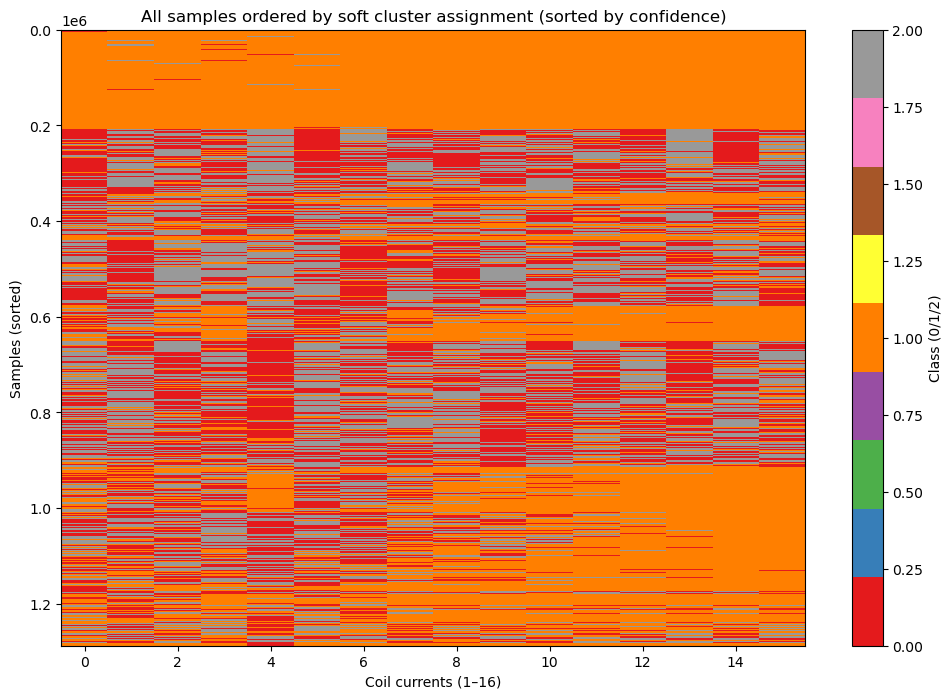

In [75]:
import numpy as np
import matplotlib.pyplot as plt

proba_cols = [c for c in I_with_patterns.columns if c.startswith("pat_")]
feat_cols  = sorted([c for c in I_with_patterns.columns if c.startswith("current_")],
                    key=lambda x: int(x.split("_")[1]))
W = I_with_patterns[proba_cols].to_numpy()    # [N, K]
Y = I_with_patterns[feat_cols].to_numpy()     # [N, 16]

# pick top cluster + confidence
top = W.argmax(axis=1)
conf = W.max(axis=1)

# sort samples: first by cluster, then by confidence (so "weak" assignments go to bottom)
order = np.lexsort((1-conf, top))  
Y_sorted = Y[order]
top_sorted = top[order]

# plot big heatmap
plt.figure(figsize=(12,8))
plt.imshow(Y_sorted, aspect="auto", cmap="Set1", interpolation="nearest")
plt.colorbar(label="Class (0/1/2)")
plt.title("All samples ordered by soft cluster assignment (sorted by confidence)")
plt.xlabel("Coil currents (1–16)")
plt.ylabel("Samples (sorted)")
plt.show()


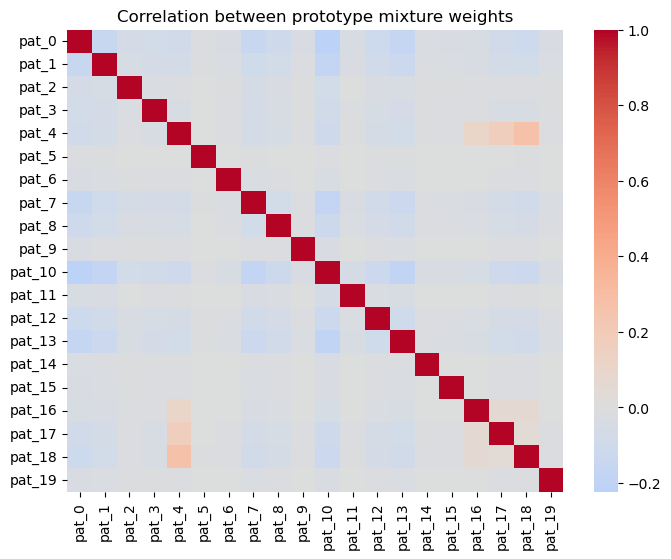

In [58]:
corr = I_with_patterns[proba_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation between prototype mixture weights")
plt.show()


In [42]:
import pandas as pd

# wrap the numpy array into a DataFrame with nice col names
X_umap10_df = pd.DataFrame(X_umap10, columns=[f"umap{i+1}" for i in range(X_umap10.shape[1])])

# save to disk (choose your path)
X_umap10_df.to_parquet("X_umap10.parquet", index=False)   # efficient binary format
# or
X_umap10_df.to_csv("X_umap10.csv", index=False)           # plain text, bigger

print("Saved:", X_umap10_df.shape)


ArrowKeyError: A type extension with name pandas.period already defined

In [82]:
import numpy as np

# your coil current columns
feat_cols = [c for c in I_with_patterns.columns if c.startswith("current_")]

# cluster labels
labels = I_with_patterns["cluster"].to_numpy()

# initialize prototype tensor: (clusters × coils × 3 classes)
D = np.zeros((gmm.n_components, len(feat_cols), 3))

for k in range(gmm.n_components):
    rows = I_with_patterns.loc[labels == k, feat_cols]
    if len(rows) == 0:
        continue
    for j, col in enumerate(feat_cols):
        vals = rows[col].values
        for c in [0, 1, 2]:
            D[k, j, c] = np.mean(vals == c)

print("D shape:", D.shape)  # should be (20, 16, 3)


D shape: (20, 16, 3)


In [83]:
import joblib, json, numpy as np, os

save_dir = "/media/alireza-linux/MagLev Simulator and Beyond/ML saved files"
os.makedirs(save_dir, exist_ok=True)

joblib.dump(svd,  os.path.join(save_dir, "svd_model.pkl"))
joblib.dump(um_hi, os.path.join(save_dir, "umap_model.pkl"))
joblib.dump(gmm,  os.path.join(save_dir, "gmm_model.pkl"))

np.save(os.path.join(save_dir, "soft_prototypes.npy"), D)

meta = {"features": feat_cols, "K": D.shape[0], "classes": [0,1,2]}
with open(os.path.join(save_dir, "training_meta.json"), "w") as f:
    json.dump(meta, f)

proba_cols = [c for c in I_with_patterns.columns if c.startswith("pat_")]
np.savez_compressed(
    os.path.join(save_dir, "assignments_full.npz"),
    labels=I_with_patterns["cluster"].to_numpy(),
    proba=I_with_patterns[proba_cols].to_numpy(dtype=np.float32),
)
